#AGENTIC RETRIEVAL
---

##0.REFERENCE AND CONTEXT

**Introduction**

Retrieval-Augmented Generation (RAG) significantly improved the reliability of Large Language Models by allowing them to retrieve external knowledge before generating answers. However, traditional RAG systems still have an important limitation: they typically perform a single retrieval step. The user asks a question, relevant documents are retrieved, and an answer is generated. While effective for straightforward questions, this approach often struggles with complex, multi-faceted problems that require investigation, decomposition, evidence evaluation, and synthesis.

Agentic Retrieval Systems address this limitation by introducing autonomous reasoning and planning capabilities into the retrieval process. Rather than treating retrieval as a single operation, an agentic system treats information gathering as an iterative workflow. The system first analyzes the user's question, develops a retrieval strategy, identifies sub-questions, gathers evidence, evaluates information quality, determines whether additional information is needed, and finally synthesizes a grounded answer.

This shift represents one of the most important developments in modern artificial intelligence. Traditional machine learning models learn patterns. RAG systems retrieve information. Agentic systems actively pursue objectives through planning, action, observation, and reflection. This ability to coordinate multiple reasoning steps moves AI closer to autonomous problem-solving.

In this notebook, students will construct a complete Agentic Retrieval System using GPT-5.2, vector embeddings, FAISS vector search, and multiple specialized agents. The system will include a Planner Agent responsible for decomposing questions, a Retriever Agent responsible for semantic search, an Evaluator Agent responsible for assessing evidence quality, and a Synthesis Agent responsible for producing a final answer.

The notebook reuses the financial knowledge base created in Chapter 14, allowing students to directly compare traditional RAG against Agentic Retrieval. By observing how multiple retrieval cycles improve evidence gathering, students will gain practical understanding of why agentic systems are becoming increasingly important in enterprise AI.

The concepts introduced here form the foundation for later chapters involving multi-agent systems, reasoning architectures, and autonomous AI workflows. Students will learn that modern AI increasingly consists of coordinated systems of agents rather than isolated models.

By the end of this chapter, students will understand planning, decomposition, retrieval loops, evidence evaluation, synthesis, and agent coordination. These capabilities represent the beginning of truly autonomous AI systems.

##1.LIBRARIES AND ENVIRONMENT

**Explanation for Cell 1**

This cell prepares the environment, installs required libraries, configures reproducibility, and creates project folders.

In [1]:
# CELL 1
# Environment Setup

!pip -q install sentence-transformers faiss-cpu openai

import json
import random
import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import faiss

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

PROJECT_DIR = Path("/content/chapter15_agentic_rag")
ARTIFACT_DIR = PROJECT_DIR / "artifacts"

ARTIFACT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RUN_ID = datetime.datetime.now(
    datetime.timezone.utc
).strftime("run_%Y%m%d_%H%M%S_utc")

print("Run ID:", RUN_ID)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 59.5 MB/s eta 0:00:00
Run ID: run_20260606_150247_utc


##2.THE SYNTHETIC DATASET

**Explanation for Cell 2**

This cell builds a synthetic financial knowledge base. The knowledge base will be searched by the retrieval agents.

In [2]:
# CELL 2
# Knowledge Base

knowledge_base = []

topics = {

    "Inflation":
        "Inflation reduces purchasing power and affects asset valuations.",

    "Bonds":
        "Bond prices typically decline when interest rates rise.",

    "Equities":
        "Equities may provide partial inflation protection over long horizons.",

    "Gold":
        "Gold is often viewed as an inflation hedge.",

    "Real Estate":
        "Real estate can benefit from rising rents during inflation.",

    "Private Credit":
        "Private credit may offer floating-rate exposure.",

    "Portfolio Diversification":
        "Diversification reduces idiosyncratic risk.",

    "Risk Management":
        "Risk management seeks to control downside exposure.",

    "Asset Allocation":
        "Asset allocation is a primary driver of long-term returns.",

    "Pension Funds":
        "Pension funds must balance liabilities and investment returns."
}

for topic, text in topics.items():

    for i in range(20):

        knowledge_base.append(
            {
                "id": len(knowledge_base),
                "topic": topic,
                "text": f"{topic}. {text}"
            }
        )

print(
    "Documents:",
    len(knowledge_base)
)

Documents: 200


##3.VECTOR EMBEDDINGS

**Explanation for Cell 3**

This cell generates vector embeddings for all documents.

In [3]:
# CELL 3
# Generate Embeddings

from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

documents = [
    doc["text"]
    for doc in knowledge_base
]

embeddings = embedding_model.encode(
    documents,
    show_progress_bar=True
)

embeddings = np.array(
    embeddings,
    dtype=np.float32
)

print(
    "Embedding Shape:",
    embeddings.shape
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Embedding Shape: (200, 384)


##4.THE FAISS VECTOR INDEX

**Explanation for Cell 4**

This cell creates the FAISS vector index used by retrieval agents.

In [4]:
# CELL 4
# Build Vector Database

embedding_dimension = embeddings.shape[1]

index = faiss.IndexFlatL2(
    embedding_dimension
)

index.add(
    embeddings
)

print(
    "Indexed Documents:",
    index.ntotal
)

Indexed Documents: 200


##5.THE PLANNER AGENT

**Explanation for Cell 5**

This cell implements the Planner Agent. The Planner decomposes a complex question into smaller sub-questions.

In [5]:
# CELL 5
# Planner Agent

from google.colab import userdata
from openai import OpenAI

client = OpenAI(
    api_key=userdata.get(
        "OPENAI_API_KEY"
    )
)

user_question = """
How should a pension fund respond
to persistent inflation?
"""

planner_prompt = f"""
You are a planning agent.

Break this question into
4 sub-questions.

Question:

{user_question}

Return JSON list.
"""

planner_response = client.responses.create(
    model="gpt-5.2",
    input=planner_prompt
)

plan = planner_response.output_text

print(plan)

[
  "What is driving the persistent inflation (demand-pull vs. cost-push, wage dynamics, supply shocks), and how might different inflation regimes affect the pension fund’s liabilities and funded status?",
  "How should the pension fund adjust its strategic asset allocation to improve inflation resilience (e.g., TIPS/linkers, real assets, equities, commodities) while respecting risk, liquidity, and regulatory constraints?",
  "What liability-hedging and actuarial actions are appropriate under persistent inflation (e.g., updating discount rates, COLA/indexation assumptions, duration/LDI positioning, contribution policy, benefit design)?",
  "What tactical, governance, and implementation steps should be taken (rebalancing rules, manager/mandate selection, derivatives/overlay use, stress testing, monitoring KPIs, and decision triggers)?"
]


##6.THE RETRIEVER AGENT

**Explanation for Cell 6**

This cell implements the Retriever Agent. The agent performs semantic search for each sub-question.

In [6]:
# CELL 6
# Retriever Agent

sub_questions = [

    "What is inflation?",

    "How does inflation affect bonds?",

    "How does inflation affect equities?",

    "What assets hedge inflation?"
]

retrieved_evidence = []

for question in sub_questions:

    query_embedding = embedding_model.encode(
        [question]
    )

    query_embedding = np.array(
        query_embedding,
        dtype=np.float32
    )

    distances, indices = index.search(
        query_embedding,
        3
    )

    retrieved_docs = [
        knowledge_base[i]
        for i in indices[0]
    ]

    retrieved_evidence.append(
        {
            "question": question,
            "documents": retrieved_docs
        }
    )

print(
    "Retrieved Evidence Sets:",
    len(retrieved_evidence)
)

Retrieved Evidence Sets: 4


##7.THE EVALUATOR AGENT

**Explanation for Cell 7**

This cell implements the Evaluator Agent. The evaluator scores the quality of retrieved evidence.

In [7]:
# CELL 7
# Evaluator Agent

evaluation_results = []

for evidence in retrieved_evidence:

    evaluation_prompt = f"""
Evaluate relevance of these documents.

Question:

{evidence['question']}

Documents:

{json.dumps(evidence['documents'], indent=2)}

Return score from 1 to 10.
"""

    response = client.responses.create(
        model="gpt-5.2",
        input=evaluation_prompt
    )

    evaluation_results.append(
        {
            "question":
                evidence["question"],

            "evaluation":
                response.output_text
        }
    )

for result in evaluation_results:

    print(result)

{'question': 'What is inflation?', 'evaluation': 'All three documents are **moderately relevant** to the question “What is inflation?” because they mention a key effect (reduced purchasing power) but don’t actually define inflation as a general rise in prices over time.\n\nScores (1–10):\n- Document 4: **6**\n- Document 5: **6**\n- Document 6: **6**'}
{'question': 'How does inflation affect bonds?', 'evaluation': 'All three documents are only **weakly relevant** to the question.\n\n- The question asks specifically about **bonds** (e.g., bond prices, yields, real returns).\n- The documents only state that inflation reduces purchasing power and affects asset valuations, without mentioning bonds or the bond-specific mechanisms.\n\n**Scores (1–10):**\n- **Doc 4:** 3/10  \n- **Doc 5:** 3/10  \n- **Doc 6:** 3/10'}
{'question': 'How does inflation affect equities?', 'evaluation': 'All three documents are directly relevant because they explicitly address the relationship between inflation and 

##8.THE AGENTIC RETRIEVAL LOOP

**Explanation for Cell 8**

This cell executes the Agentic Retrieval Loop. Evidence from multiple retrieval tasks is consolidated.

In [8]:
# CELL 8
# Multi-Step Retrieval Loop

all_context = []

for evidence in retrieved_evidence:

    for doc in evidence["documents"]:

        all_context.append(
            doc["text"]
        )

all_context = list(
    set(all_context)
)

print(
    "Context Documents:",
    len(all_context)
)

Context Documents: 3


##9.THE SYNTHESIS AGENT

**Explanation for Cell 9**

This cell implements the Synthesis Agent. The agent generates a final grounded answer using all collected evidence.

In [9]:
# CELL 9
# Synthesis Agent

context = "\n\n".join(
    all_context
)

synthesis_prompt = f"""
You are a synthesis agent.

Question:

{user_question}

Evidence:

{context}

Produce a comprehensive answer.
"""

response = client.responses.create(
    model="gpt-5.2",
    input=synthesis_prompt
)

final_answer = response.output_text

print(final_answer)

A pension fund should respond to persistent inflation with a deliberate, multi‑layer strategy that (1) measures and manages *real* (inflation‑adjusted) liabilities, (2) improves inflation resilience of the asset portfolio, (3) strengthens governance and rebalancing discipline, and (4) updates funding and contribution policies to reflect the new regime.

## 1) Start from the liabilities: manage the fund in real terms
Persistent inflation is primarily a *liability problem* for pension funds, because benefit promises (explicitly or implicitly) often rise with inflation.

- **Diagnose inflation linkage in liabilities**
  - Are benefits indexed to CPI (full, capped, or conditional)?
  - Are wage growth and inflation correlated in the plan’s liability model?
  - What is the plan’s exposure to *unexpected* inflation vs *expected* inflation?

- **Shift monitoring to real metrics**
  - Track **real funded status** (assets vs inflation-adjusted liabilities).
  - Stress test scenarios: sustained 

##10.THE WORKFLOW

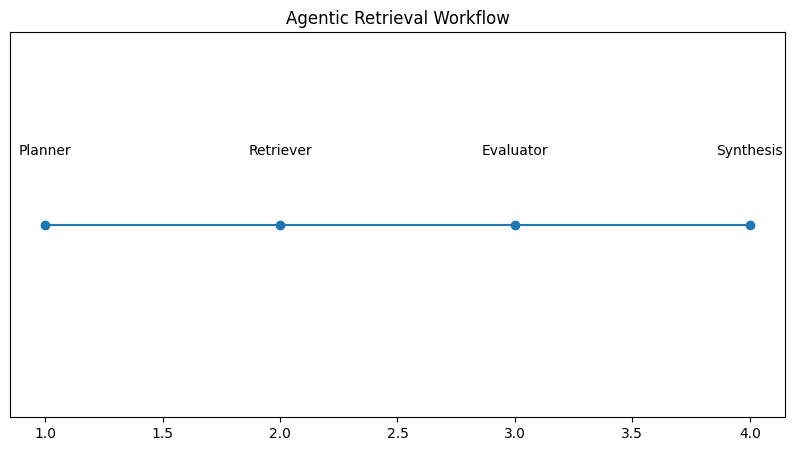

In [10]:
# CELL 10
# Agent Trace Visualization

agents = [
    "Planner",
    "Retriever",
    "Evaluator",
    "Synthesis"
]

steps = [1, 2, 3, 4]

plt.figure(
    figsize=(10,5)
)

plt.plot(
    steps,
    [1,1,1,1],
    marker="o"
)

for i, agent in enumerate(agents):

    plt.text(
        steps[i],
        1.02,
        agent,
        ha="center"
    )

plt.yticks([])
plt.title(
    "Agentic Retrieval Workflow"
)

plt.show()

##11.SUMMARIZATION AND EXPLANATION

In [11]:
# CELL 11
# GPT-5.2 Notebook Analysis

summary = {

    "question":
        user_question,

    "sub_questions":
        len(sub_questions),

    "retrieved_documents":
        len(all_context),

    "agents":
        agents
}

response = client.responses.create(
    model="gpt-5.2",
    input=f"""
Explain this Agentic Retrieval System.

Return strict JSON.

{json.dumps(summary, indent=2)}
"""
)

print(
    response.output_text
)

{
  "overview": "An Agentic Retrieval System is a multi-step, multi-agent workflow that answers a user’s question by (1) planning what to ask, (2) retrieving evidence, (3) checking evidence quality and relevance, and (4) synthesizing a final answer grounded in the retrieved sources. It is “agentic” because specialized agents make decisions (what to search, what to keep, what to ask next) rather than doing a single-pass retrieval + generation.",
  "input": {
    "question": "How should a pension fund respond to persistent inflation?",
    "sub_questions": 4,
    "retrieved_documents": 3,
    "agents": [
      "Planner",
      "Retriever",
      "Evaluator",
      "Synthesis"
    ]
  },
  "agent_roles": {
    "Planner": {
      "purpose": "Decompose the main question into targeted sub-questions and define what evidence is needed.",
      "outputs": [
        "4 sub-questions",
        "search plan (topics, keywords, constraints like jurisdiction, risk budget, time horizon)"
      ]
    }

##12.CONCLUSIONS

**Conclusion**

This chapter introduced Agentic Retrieval Systems, representing a major evolution beyond traditional Retrieval-Augmented Generation. Rather than performing a single retrieval operation, the system decomposed a complex problem into multiple investigative tasks, gathered evidence from multiple perspectives, evaluated information quality, and synthesized a comprehensive response.

Students observed how specialized agents can cooperate to solve complex problems. The Planner Agent analyzed the question and identified the information required. The Retriever Agent gathered relevant evidence using semantic search. The Evaluator Agent assessed evidence quality and relevance. Finally, the Synthesis Agent integrated information into a coherent answer. This workflow mirrors many modern enterprise AI systems.

The transition from RAG to Agentic Retrieval is significant because it introduces autonomous behavior. Traditional retrieval systems respond to questions. Agentic systems actively pursue information, evaluate results, and adapt their actions. This capability allows AI systems to address more sophisticated tasks requiring planning, decomposition, and reflection.

The notebook also demonstrated the importance of retrieval loops. Complex questions often require evidence from multiple domains. By retrieving information iteratively rather than relying on a single search, agentic systems can build richer contextual understanding and produce more robust answers.

An important lesson from this chapter is that modern AI increasingly consists of systems rather than individual models. Planning, retrieval, evaluation, and synthesis are distinct functions that can be distributed across specialized agents. This modular design improves transparency, flexibility, and performance.

The concepts introduced here form the foundation for many emerging AI architectures. Research assistants, legal analysis systems, financial advisory platforms, and scientific discovery tools increasingly employ agentic workflows similar to those demonstrated in this notebook.

Most importantly, students learned that intelligence is not solely about generating answers. Intelligence also involves deciding what information is needed, determining how to obtain it, evaluating its quality, and integrating it into a coherent response. These capabilities are central to autonomous reasoning systems.

The next chapter moves from retrieval systems to Fine-Tuning Foundation Models. Students will learn how large language models can be adapted to specialized domains, creating systems with expertise tailored to specific tasks and industries.